<a href="https://colab.research.google.com/github/JCbarajas5/Machine-Learning-Anahuac/blob/main/Clustering_Usuarios_secc1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Segmentación de Usuarios en Tienda Online mediante Clustering**

**Materia:** Machine Learning  
**Dataset:** product.csv — Tienda online de artículos deportivos

---
## Contexto
Una tienda online de artículos deportivos muestra banners aleatoriamente en su página principal.  
El objetivo es segmentar usuarios con K-Means, Mean-Shift y DBSCAN para apoyar la decisión  
del gerente entre modelo CPC vs. personalización basada en segmentación.

---

## FASE 1: Exploración y Preparación de Datos
### 1.1 Análisis Exploratorio (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

# Carga del dataset
df = pd.read_csv('Data/product.csv', parse_dates=['time'], dayfirst=True)

print('=== DIMENSIONES ===')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')

print('\n=== TIPOS DE DATOS ===')
print(df.dtypes)

print('\n=== PRIMERAS FILAS ===')
display(df.head(10))

=== DIMENSIONES ===
Filas: 1,048,575  |  Columnas: 8

=== TIPOS DE DATOS ===
order_id                   str
user_id                    str
page_id                    str
product                    str
site_version               str
time            datetime64[us]
title                      str
target                   int64
dtype: object

=== PRIMERAS FILAS ===


,order_id,user_id,page_id,product,site_version,time,title,target
0,cfcd208495d565ef66e7dff9f98764da,c81e728d9d4c2f636f067f89cc14862c,6f4922f45568161a8cdf4ad2299f6d23,sneakers,desktop,2019-01-11 09:24:00,banner_click,0
1,c4ca4238a0b923820dcc509a6f75849b,eccbc87e4b5ce2fe28308fd9f2a7baf3,4e732ced3463d06de0ca9a15b6153677,sneakers,desktop,2019-01-09 09:38:00,banner_show,0
2,c81e728d9d4c2f636f067f89cc14862c,eccbc87e4b5ce2fe28308fd9f2a7baf3,5c45a86277b8bf17bff6011be5cfb1b9,sports_nutrition,desktop,2019-01-09 09:12:00,banner_show,0
3,eccbc87e4b5ce2fe28308fd9f2a7baf3,eccbc87e4b5ce2fe28308fd9f2a7baf3,fb339ad311d50a229e497085aad219c7,company,desktop,2019-01-03 08:58:00,banner_show,0
4,a87ff679a2f3e71d9181a67b7542122c,eccbc87e4b5ce2fe28308fd9f2a7baf3,fb339ad311d50a229e497085aad219c7,company,desktop,2019-01-03 08:59:00,banner_click,0
5,e4da3b7fbbce2345d7772b0674a318d5,a87ff679a2f3e71d9181a67b7542122c,182be0c5cdcd5072bb1864cdee4d3d6e,sports_nutrition,mobile,2019-01-14 05:33:00,banner_show,0
6,1679091c5a880faf6fb5e6087eb1b2dc,e4da3b7fbbce2345d7772b0674a318d5,e369853df766fa44e1ed0ff613f563bd,sneakers,mobile,2019-03-02 15:10:00,banner_show,0
7,8f14e45fceea167a5a36dedd4bea2543,1679091c5a880faf6fb5e6087eb1b2dc,1c383cd30b7c298ab50293adfecb7b18,sneakers,desktop,2019-02-10 12:19:00,banner_show,0
8,c9f0f895fb98ab9159f51fd0297e236d,8f14e45fceea167a5a36dedd4bea2543,17e62166fc8586dfa4d1bc0e1742c08b,accessories,desktop,2019-02-06 05:21:00,banner_show,0
9,45c48cce2e2d7fbdea1afc51c7c6ad26,8f14e45fceea167a5a36dedd4bea2543,2ff279ece91cd2eaae06e449f5a20a0c,clothes,desktop,2019-01-24 10:36:00,banner_show,0


In [ ]:
print('=== VALORES FALTANTES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({'Faltantes': missing, '% del total': missing_pct}))

print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
display(df.describe(include='all'))

=== VALORES FALTANTES ===


,Faltantes,% del total
order_id,0,0.0
user_id,0,0.0
page_id,0,0.0
product,0,0.0
site_version,0,0.0
time,0,0.0
title,0,0.0
target,0,0.0



=== ESTADÍSTICAS DESCRIPTIVAS ===


,order_id,user_id,page_id,product,site_version,time,title,target
count,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1.048575e+06
unique,1048575,423222,914932,5,2,NaN,3,NaN
top,cfcd208495d565ef66e7dff9f98764da,aa33d045826d234eb5858674dbfe93f2,a3d2de7675556553a5f08e4c88d2c228,company,mobile,NaN,banner_show,NaN
freq,1,22,30805,235185,761333,NaN,914930,NaN
mean,NaN,NaN,NaN,NaN,NaN,2019-02-10 05:10:01.235333,NaN,2.937797e-02
min,NaN,NaN,NaN,NaN,NaN,2019-01-01 00:00:00,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,2019-01-17 17:50:00,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,2019-02-04 13:31:00,NaN,0.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,2019-02-22 14:10:00,NaN,0.000000e+00
max,NaN,NaN,NaN,NaN,NaN,2019-05-31 23:43:00,NaN,1.000000e+00


In [ ]:
# Conteos clave
n_users    = df['user_id'].nunique()
n_products = df['product'].nunique()
n_events   = len(df)

print(f'Usuarios únicos   : {n_users:,}')
print(f'Productos únicos  : {n_products}')
print(f'Total de eventos  : {n_events:,}')

print('\n=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===')
event_counts = df['title'].value_counts()
display(event_counts)

print('\n=== DISTRIBUCIÓN MOBILE vs DESKTOP ===')
display(df['site_version'].value_counts())

print('\n=== PRODUCTOS MÁS POPULARES ===')
display(df['product'].value_counts())

Usuarios únicos   : 423,222
Productos únicos  : 5
Total de eventos  : 1,048,575

=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===


title
banner_show     914930
banner_click    102840
order            30805
Name: count, dtype: int64


=== DISTRIBUCIÓN MOBILE vs DESKTOP ===


site_version
mobile     761333
desktop    287242
Name: count, dtype: int64


=== PRODUCTOS MÁS POPULARES ===


product
company             235185
clothes             215973
sneakers            205486
accessories         196803
sports_nutrition    195128
Name: count, dtype: int64

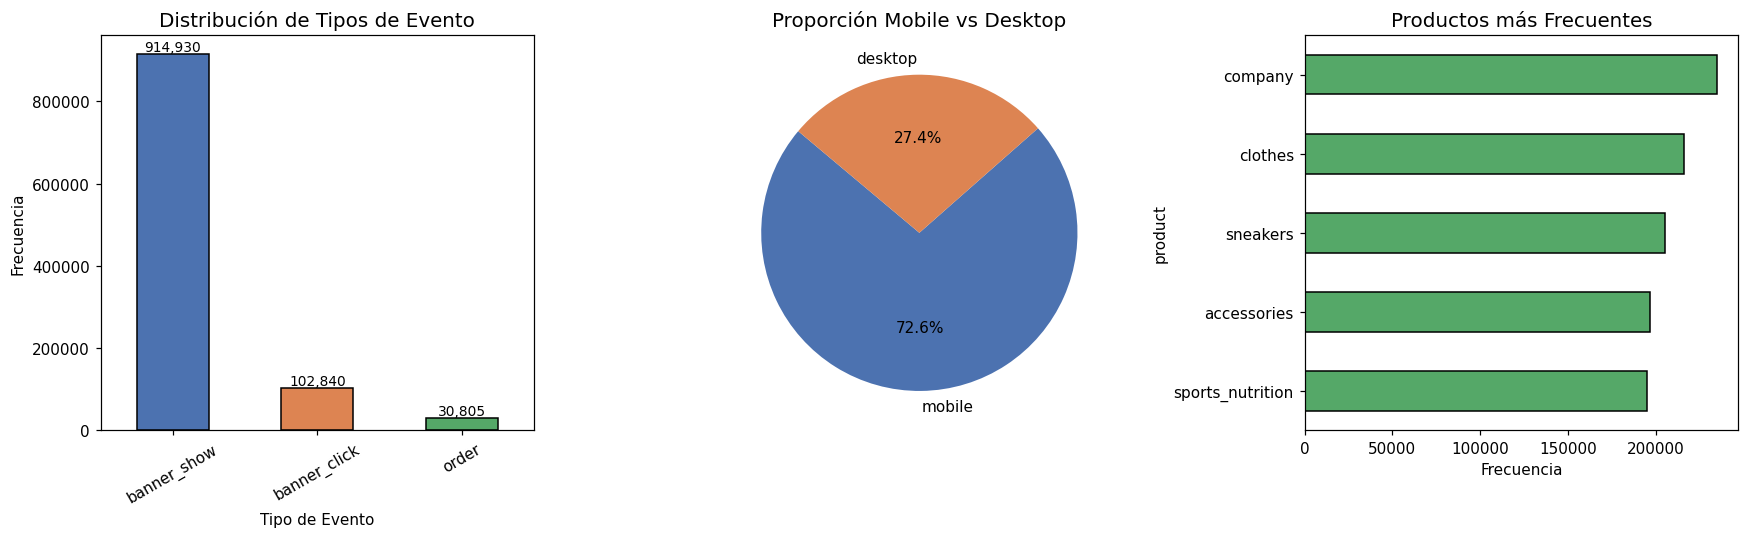

Figura guardada: eda_distribucion_eventos.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de eventos
event_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[0].set_title('Distribución de Tipos de Evento')
axes[0].set_xlabel('Tipo de Evento')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Mobile vs Desktop
version_counts = df['site_version'].value_counts()
axes[1].pie(version_counts, labels=version_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=140)
axes[1].set_title('Proporción Mobile vs Desktop')

# Productos más frecuentes
prod_counts = df['product'].value_counts()
prod_counts.plot(kind='barh', ax=axes[2], color='#55A868', edgecolor='black')
axes[2].set_title('Productos más Frecuentes')
axes[2].set_xlabel('Frecuencia')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_distribucion_eventos.png', bbox_inches='tight')
plt.show()
print('Figura guardada: eda_distribucion_eventos.png')

---
### 1.2 Ingeniería de Características
Creamos una matriz de usuarios donde cada fila representa un usuario único con sus características de comportamiento.

In [ ]:
# Clasificar eventos por tipo
df['is_show']     = (df['title'] == 'banner_show').astype(int)
df['is_click']    = (df['title'] == 'banner_click').astype(int)
df['is_purchase'] = (df['title'] == 'order').astype(int)
df['is_mobile']   = (df['site_version'] == 'mobile').astype(int)
df['is_desktop']  = (df['site_version'] == 'desktop').astype(int)

# Ordenar por usuario y tiempo para calcular tiempo entre eventos
df = df.sort_values(['user_id', 'time'])

# Tiempo entre eventos consecutivos por usuario (en horas)
df['time_diff_hours'] = df.groupby('user_id')['time'].diff().dt.total_seconds() / 3600

print('Columnas auxiliares creadas correctamente.')
display(df[['user_id','title','site_version','is_show','is_click','is_purchase','time_diff_hours']].head(10))

Columnas auxiliares creadas correctamente.


,user_id,title,site_version,is_show,is_click,is_purchase,time_diff_hours
15512,00003e3b9e5336685200ae85d21b4f5e,banner_show,mobile,1,0,0,NaN
15511,00003e3b9e5336685200ae85d21b4f5e,banner_show,mobile,1,0,0,23.833333
207588,000053b1e684c9e7ea73727b2238ce18,banner_show,mobile,1,0,0,NaN
614604,00005d011db80a956aab176cc94d1d37,banner_show,mobile,1,0,0,NaN
1028653,0000a0f5746d603088ac968c91b085b5,banner_show,mobile,1,0,0,NaN
499809,0000b2815cc3c2b56867cbbf4d36efa5,banner_show,mobile,1,0,0,NaN
989965,0000e9af7421452e8001a374085ca53b,banner_show,desktop,1,0,0,NaN
989964,0000e9af7421452e8001a374085ca53b,banner_show,desktop,1,0,0,112.083333
989967,0000e9af7421452e8001a374085ca53b,banner_click,desktop,0,1,0,0.000000
989966,0000e9af7421452e8001a374085ca53b,banner_show,desktop,1,0,0,539.666667


In [ ]:
from scipy.stats import entropy as scipy_entropy

# Función de diversidad de Shannon
def shannon_diversity(series):
    counts = series.value_counts()
    probs = counts / counts.sum()
    return scipy_entropy(probs, base=2)

# Agregar características base por usuario
agg = df.groupby('user_id').agg(
    total_interactions = ('order_id', 'count'),
    total_shows        = ('is_show', 'sum'),
    total_clicks       = ('is_click', 'sum'),
    total_purchases    = ('is_purchase', 'sum'),
    mobile_events      = ('is_mobile', 'sum'),
    desktop_events     = ('is_desktop', 'sum'),
    avg_time_between_events = ('time_diff_hours', 'mean'),
    days_active        = ('time', lambda x: x.dt.date.nunique()),
).reset_index()

# Productos vistos (clics) y comprados por usuario
clicks_df = df[df['is_click'] == 1]
purchases_df = df[df['is_purchase'] == 1]

products_viewed = clicks_df.groupby('user_id')['product'].nunique().rename('products_viewed')
products_purchased = purchases_df.groupby('user_id')['product'].nunique().rename('products_purchased')

# Diversidad de productos (Shannon) sobre clics
product_diversity = clicks_df.groupby('user_id')['product'].apply(shannon_diversity).rename('avg_product_diversity')

# Unir todo
users = agg.merge(products_viewed, on='user_id', how='left')\
           .merge(products_purchased, on='user_id', how='left')\
           .merge(product_diversity, on='user_id', how='left')

# Rellenar NaN con 0 (usuarios sin clics/compras)
users[['products_viewed','products_purchased','avg_product_diversity']] = \
    users[['products_viewed','products_purchased','avg_product_diversity']].fillna(0)

users['avg_time_between_events'] = users['avg_time_between_events'].fillna(0)

print(f'Usuarios en la matriz: {len(users):,}')
display(users.head())

Usuarios en la matriz: 423,222


,user_id,total_interactions,total_shows,total_clicks,total_purchases,mobile_events,desktop_events,avg_time_between_events,days_active,products_viewed,products_purchased,avg_product_diversity
0,00003e3b9e5336685200ae85d21b4f5e,2,2,0,0,2,0,23.833333,2,0.0,0.0,0.0
1,000053b1e684c9e7ea73727b2238ce18,1,1,0,0,1,0,0.000000,1,0.0,0.0,0.0
2,00005d011db80a956aab176cc94d1d37,1,1,0,0,1,0,0.000000,1,0.0,0.0,0.0
3,0000a0f5746d603088ac968c91b085b5,1,1,0,0,1,0,0.000000,1,0.0,0.0,0.0
4,0000b2815cc3c2b56867cbbf4d36efa5,1,1,0,0,1,0,0.000000,1,0.0,0.0,0.0


In [ ]:
# Características derivadas (manejo de divisiones por cero)
users['mobile_percentage']   = users['mobile_events'] / users['total_interactions']
users['desktop_percentage']  = users['desktop_events'] / users['total_interactions']

# click_to_purchase_ratio: clics / compras (0 si sin compras)
users['click_to_purchase_ratio'] = np.where(
    users['total_purchases'] > 0,
    users['total_clicks'] / users['total_purchases'],
    0
)

# show_to_click_ratio: shows / clicks (0 si sin clics)
users['show_to_click_ratio'] = np.where(
    users['total_clicks'] > 0,
    users['total_shows'] / users['total_clicks'],
    0
)

# purchase_frequency: compras por día activo
users['purchase_frequency'] = np.where(
    users['days_active'] > 0,
    users['total_purchases'] / users['days_active'],
    0
)

# Seleccionar columnas finales para la matriz de features
feature_cols = [
    'total_interactions',
    'total_clicks',
    'total_purchases',
    'click_to_purchase_ratio',
    'mobile_percentage',
    'desktop_percentage',
    'avg_time_between_events',
    'products_viewed',
    'products_purchased',
    'avg_product_diversity',
    'show_to_click_ratio',
    'days_active',
    'purchase_frequency',
]

X_raw = users[feature_cols].copy()
print(f'Matriz de features: {X_raw.shape[0]:,} usuarios × {X_raw.shape[1]} características')
print('\nEstadísticas descriptivas de features:')
display(X_raw.describe().T)

Matriz de features: 423,222 usuarios × 13 características

Estadísticas descriptivas de features:


,count,mean,std,min,25%,50%,75%,max
total_interactions,423222.0,2.477600,2.249639,1.0,1.0,2.0,3.000000,22.000000
total_clicks,423222.0,0.242993,0.523522,0.0,0.0,0.0,0.000000,7.000000
total_purchases,423222.0,0.072787,0.280617,0.0,0.0,0.0,0.000000,5.000000
click_to_purchase_ratio,423222.0,0.041249,0.246527,0.0,0.0,0.0,0.000000,7.000000
mobile_percentage,423222.0,0.678008,0.465460,0.0,0.0,1.0,1.000000,1.000000
desktop_percentage,423222.0,0.321992,0.465460,0.0,0.0,0.0,1.000000,1.000000
avg_time_between_events,423222.0,164.528425,342.583630,0.0,0.0,6.6,183.533333,3568.733333
products_viewed,423222.0,0.231117,0.482703,0.0,0.0,0.0,0.000000,5.000000
products_purchased,423222.0,0.071157,0.270312,0.0,0.0,0.0,0.000000,4.000000
avg_product_diversity,423222.0,0.023396,0.158085,0.0,0.0,0.0,0.000000,2.321928


In [ ]:
# Eliminar características con varianza cero
zero_var_cols = X_raw.columns[X_raw.var() == 0].tolist()
if zero_var_cols:
    print(f'Eliminando columnas con varianza cero: {zero_var_cols}')
    X_raw = X_raw.drop(columns=zero_var_cols)
    feature_cols = [c for c in feature_cols if c not in zero_var_cols]
else:
    print('No hay columnas con varianza cero.')

# Estandarización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f'\nMedia post-escalado (deben ser ~0):')
print(X_scaled_df.mean().round(6).to_string())
print(f'\nCaracterísticas finales: {len(feature_cols)}')

No hay columnas con varianza cero.

Media post-escalado (deben ser ~0):
total_interactions        -0.0
total_clicks               0.0
total_purchases           -0.0
click_to_purchase_ratio    0.0
mobile_percentage         -0.0
desktop_percentage         0.0
avg_time_between_events    0.0
products_viewed           -0.0
products_purchased        -0.0
avg_product_diversity     -0.0
show_to_click_ratio        0.0
days_active               -0.0
purchase_frequency        -0.0

Características finales: 13


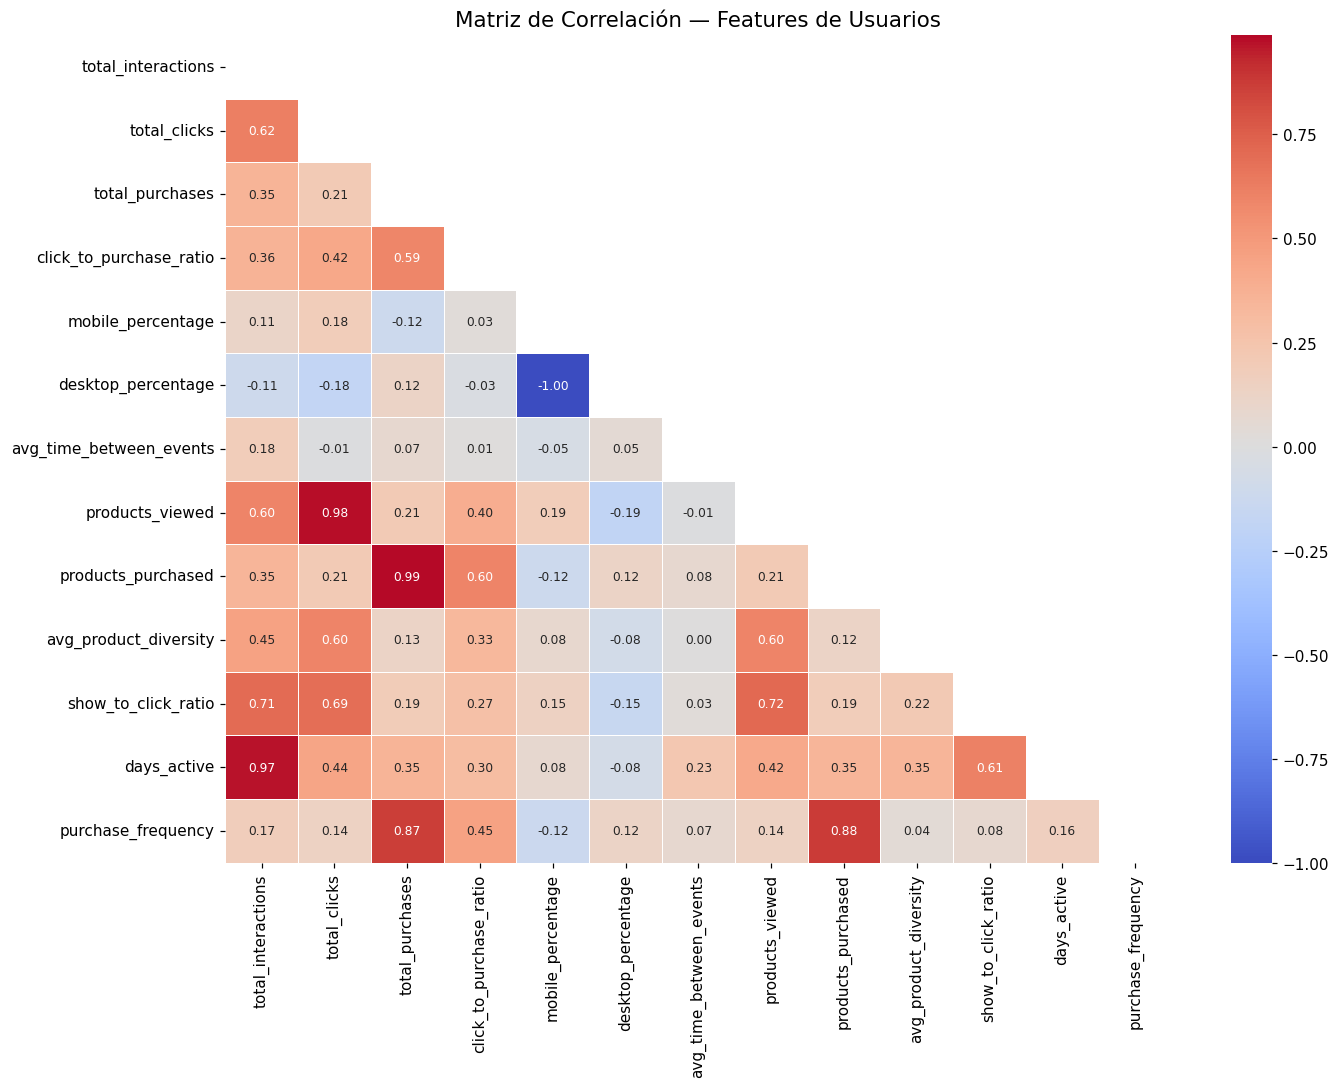

Figura guardada: correlacion_features.png


In [ ]:
# Heatmap de correlación
corr = X_raw.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación — Features de Usuarios', fontsize=14)
plt.tight_layout()
plt.savefig('correlacion_features.png', bbox_inches='tight')
plt.show()
print('Figura guardada: correlacion_features.png')

---
### 1.3 Análisis de Multicolinealidad y Reducción de Dimensionalidad

In [ ]:
# Detectar pares altamente correlacionados (|r| > 0.75)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.75:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

print('=== PARES CON |r| > 0.75 ===')
if high_corr_pairs:
    for a, b, r in high_corr_pairs:
        print(f'  {a}  ↔  {b}  →  r = {r}')
else:
    print('  No se encontraron pares con alta correlación.')

=== PARES CON |r| > 0.75 ===
  total_interactions  ↔  days_active  →  r = 0.967
  total_clicks  ↔  products_viewed  →  r = 0.976
  total_purchases  ↔  products_purchased  →  r = 0.989
  total_purchases  ↔  purchase_frequency  →  r = 0.867
  mobile_percentage  ↔  desktop_percentage  →  r = -1.0
  products_purchased  ↔  purchase_frequency  →  r = 0.879


Componentes para 90% de varianza: 6
Componentes para 95% de varianza: 7


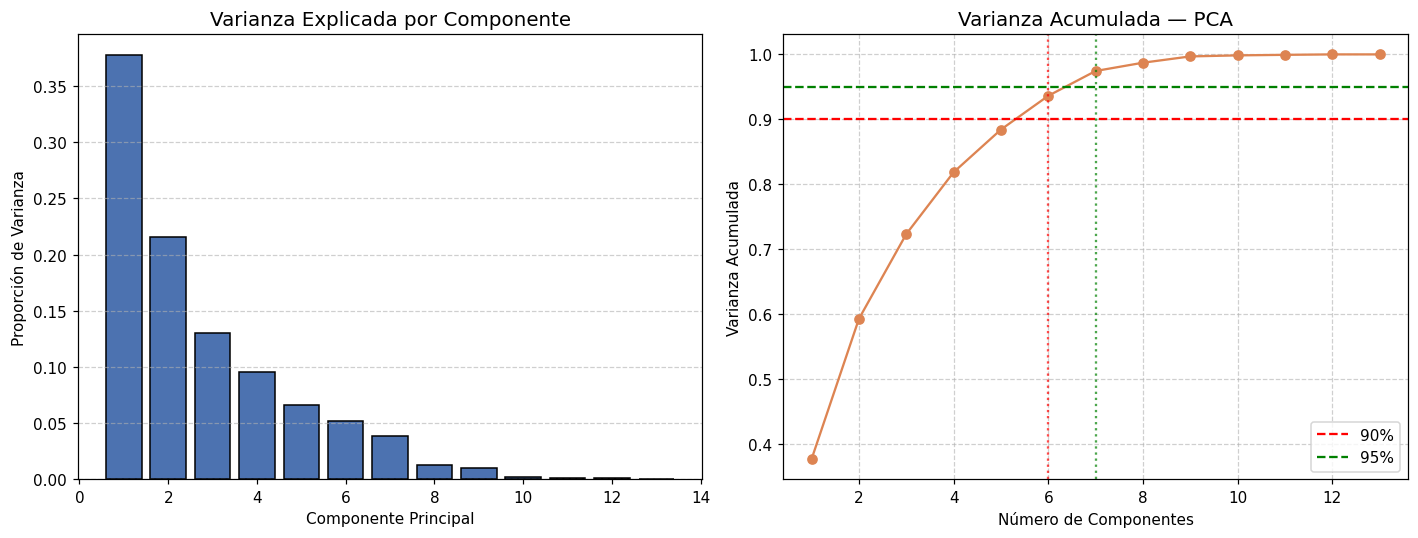

Figura guardada: pca_varianza.png


In [ ]:
from sklearn.decomposition import PCA

# PCA completo para analizar varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Número de componentes para 90% y 95% de varianza
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print(f'Componentes para 90% de varianza: {n_90}')
print(f'Componentes para 95% de varianza: {n_95}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Varianza individual
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#4C72B0', edgecolor='black')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Proporción de Varianza')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Varianza acumulada
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='#DD8452')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95%')
axes[1].axvline(x=n_90, color='red', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_95, color='green', linestyle=':', alpha=0.7)
axes[1].set_title('Varianza Acumulada — PCA')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('pca_varianza.png', bbox_inches='tight')
plt.show()
print('Figura guardada: pca_varianza.png')

In [ ]:
# Aplicar PCA con n_90 componentes para clustering
pca = PCA(n_components=n_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Dimensión original : {X_scaled.shape[1]} características')
print(f'Dimensión reducida : {X_pca.shape[1]} componentes principales')
print(f'Varianza explicada : {pca.explained_variance_ratio_.sum():.2%}')

# Interpretación de los primeros 3 componentes
components_df = pd.DataFrame(
    pca.components_[:3],
    columns=feature_cols,
    index=[f'PC{i+1}' for i in range(3)]
)
print('\nCargas de los primeros 3 componentes principales:')
display(components_df.T.style.background_gradient(cmap='RdYlGn', axis=None))

Dimensión original : 13 características
Dimensión reducida : 6 componentes principales
Varianza explicada : 93.63%

Cargas de los primeros 3 componentes principales:


,PC1,PC2,PC3
total_interactions,0.378686,-0.125082,-0.168802
total_clicks,0.359201,-0.226761,-0.114459
total_purchases,0.292824,0.406120,0.207525
click_to_purchase_ratio,0.295859,0.162319,0.140979
mobile_percentage,0.060000,-0.367277,0.588096
desktop_percentage,-0.060000,0.367277,-0.588096
avg_time_between_events,0.054570,0.048421,-0.118542
products_viewed,0.356138,-0.229328,-0.114723
products_purchased,0.292781,0.409245,0.213307
avg_product_diversity,0.250194,-0.159276,-0.140374


Proyección 2D — Varianza explicada: 59.30%


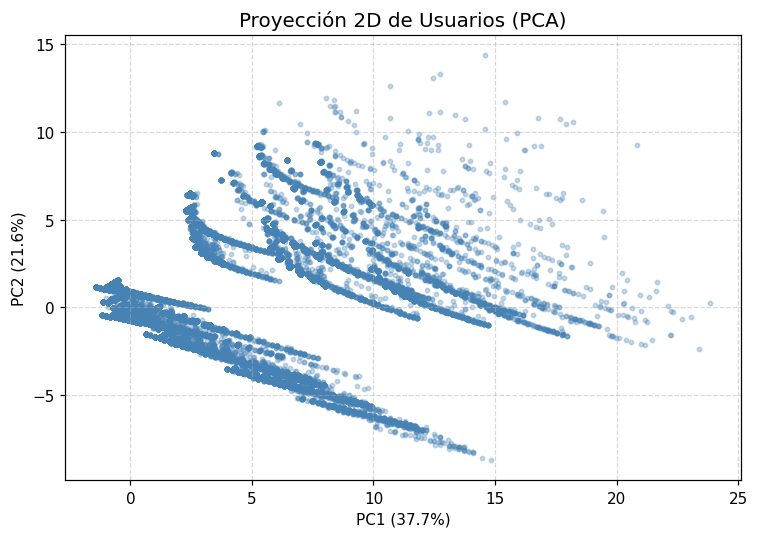

In [ ]:
# Guardar también versión 2D para visualizaciones
pca2d = PCA(n_components=2, random_state=42)
X_2d = pca2d.fit_transform(X_scaled)
print(f'Proyección 2D — Varianza explicada: {pca2d.explained_variance_ratio_.sum():.2%}')

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=8, color='steelblue')
plt.xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
plt.title('Proyección 2D de Usuarios (PCA)')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pca_2d_usuarios.png', bbox_inches='tight')
plt.show()